In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'usecase':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# Use Case 1: Corporate Future Debt Issuance Hedge

## Business Scenario

A corporate treasurer expects to issue **new fixed-rate debt in 2028** and wants protection against higher market rates before the issuance date.
The planned financing profile is:

- Hedge decision date: market snapshot date in the project
- Planned issuance year: `2028`
- Planned debt amount: `USD 50,000,000`
- Planned debt maturity at issuance: `5 years`

A practical hedge is to buy a **2Y x 5Y payer swaption**. If future swap rates rise before issuance, the swaption should gain value and partially offset the higher coupon the issuer would have to pay on the new bond.

This notebook focuses on a single pricing framework only:

- `SABR-adjusted Black`

The goal is not to compare models, but to examine how the hedge behaves under multiple future rate scenarios.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from swaption_pricing.data import load_curve_points_csv
from swaption_pricing.market import load_json_metadata
from swaption_pricing.risk import parallel_shift_curve
from swaption_pricing.pricing.european import SabrParams, price_swaption_with_sabr
from swaption_pricing.core import forward_swap_rate, swap_annuity
from swaption_pricing.types import SwaptionSpec


## Market Inputs

This use case uses the public U.S. Treasury yield-curve proxy already fetched into the project.
That means the curve is **market-connected**, but still a **proxy** rather than a full dealer-grade SOFR swap curve.

For the volatility side, we use a SABR parameter set as the pricing layer for a smile-aware swaption premium:

- `alpha = 0.0200`
- `beta = 0.50`
- `rho = -0.25`
- `nu = 0.40`

These are still project assumptions rather than vendor swaption quotes, but they allow us to illustrate a realistic smile-adjusted hedge valuation workflow.


In [3]:
curve_path = PROJECT_ROOT / 'data/european/market/ust_yield_curve_proxy/curve_points.csv'
metadata_path = PROJECT_ROOT / 'data/european/market/ust_yield_curve_proxy/ust_yield_curve_snapshot.json'

curve = load_curve_points_csv(curve_path)
curve_metadata = load_json_metadata(metadata_path)
curve_metadata


{'yield_curve_date': '2026-06-12',
 'ff_target_upper': 3.75,
 'ff_target_lower': 3.5,
 'rrp_award_rate': 3.5,
 'cpiu_latest_reading': 4.2,
 'cpiu_latest_reading_date': '2026-05-01',
 'yield_1m': 3.69,
 'yield_2m': 3.7,
 'yield_3m': 3.78,
 'yield_4m': 3.79,
 'yield_6m': 3.82,
 'yield_1y': 3.86,
 'yield_2y': 4.09,
 'yield_3y': 4.12,
 'yield_5y': 4.21,
 'yield_7y': 4.34,
 'yield_10y': 4.48,
 'yield_20y': 4.98,
 'yield_30y': 4.97,
 'recession': False}

## Hedge Setup

Representative hedge instrument:

- Hedge instrument: `2Y x 5Y payer swaption`
- Notional: `USD 50,000,000`
- Expiry: `2Y`
- Underlying swap tenor: `5Y`
- Strike: current ATM forward swap rate

We use the current `2Y x 5Y` forward swap rate as a simple proxy for the issuer's future all-in fixed-rate funding level before credit spread adjustments.


In [4]:
notional = 50_000_000.0
expiry = 2.0
tenor = 5.0
pay_frequency = 1
option_type = 'payer'

valuation_date = curve_metadata['yield_curve_date']
planned_issuance_year = 2028
planned_debt_maturity_years = tenor

atm_strike = forward_swap_rate(curve, expiry, tenor, pay_frequency)
spec = SwaptionSpec(
    notional=notional,
    expiry=expiry,
    tenor=tenor,
    strike=atm_strike,
    pay_frequency=pay_frequency,
    option_type=option_type,
)

sabr_params = SabrParams(alpha=0.0200, beta=0.50, rho=-0.25, nu=0.40)

base_forward = forward_swap_rate(curve, expiry, tenor, pay_frequency)
base_annuity = swap_annuity(curve, expiry, tenor, pay_frequency)
base_price, base_sabr_vol = price_swaption_with_sabr(curve, spec, sabr_params)

setup_df = pd.DataFrame([
    {
        'valuation_date': valuation_date,
        'planned_issuance_year': planned_issuance_year,
        'planned_debt_amount': notional,
        'planned_debt_maturity_years': planned_debt_maturity_years,
        'base_forward_funding_proxy': base_forward,
        'annuity': base_annuity,
        'sabr_implied_vol': base_sabr_vol,
        'base_swaption_premium': base_price,
    }
])
setup_df


,valuation_date,planned_issuance_year,planned_debt_amount,planned_debt_maturity_years,base_forward_funding_proxy,annuity,sabr_implied_vol,base_swaption_premium
0,2026-06-12,2028,50000000.0,5.0,0.045271,4.052214,0.096066,496757.928504


## Key Modelling Assumptions

This use case is intentionally practical but still simplified. The main assumptions are:

- `Future debt cost proxy`: the issuer's future benchmark funding level is proxied by the `2Y x 5Y` forward swap rate rather than a full corporate bond yield model
- `Credit spread`: issuer-specific credit spread and any new-issue premium are held outside the model
- `Hedge ratio`: the swaption notional is assumed to match the planned debt amount one-for-one for illustration
- `Volatility input`: SABR parameters are illustrative and not calibrated to a live market smile slice
- `Scenario engine`: rate scenarios are modeled as parallel shifts to the curve rather than full curve-shape or spread scenarios

These assumptions are acceptable for a benchmark-rate hedge study, but a production corporate treasury framework would refine each of them.


## Scenario Design

We study three broad future-rate regimes, each with **5 rate points**:

- `Falling`: rates drift steadily lower before issuance
- `Unchanged`: rates remain near the current forward level
- `Rising`: rates drift steadily higher before issuance

For each scenario point, we evaluate:

1. Future funding-rate proxy
2. Debt-cost change without hedge
3. Swaption value and swaption PnL
4. Net funding-cost impact after hedge


In [5]:
scenario_definitions = {
    'falling': [-0.0100, -0.0075, -0.0050, -0.0025, -0.0010],
    'unchanged': [-0.0010, -0.0005, 0.0000, 0.0005, 0.0010],
    'rising': [0.0010, 0.0025, 0.0050, 0.0075, 0.0100],
}

scenario_rows = []
for regime, shocks in scenario_definitions.items():
    for idx, shock in enumerate(shocks, start=1):
        shocked_curve = parallel_shift_curve(curve, shock)
        shocked_forward = forward_swap_rate(shocked_curve, expiry, tenor, pay_frequency)
        shocked_price, shocked_sabr_vol = price_swaption_with_sabr(shocked_curve, spec, sabr_params)
        swaption_pnl = shocked_price - base_price
        annual_coupon_cost_change = notional * (shocked_forward - base_forward)
        five_year_total_cost_change = annual_coupon_cost_change * planned_debt_maturity_years
        net_cost_after_hedge = five_year_total_cost_change - swaption_pnl
        scenario_rows.append({
            'regime': regime,
            'scenario_point': idx,
            'rate_shift_bp': shock * 10000,
            'future_funding_rate_proxy': shocked_forward,
            'annual_coupon_cost_change': annual_coupon_cost_change,
            'five_year_total_cost_change': five_year_total_cost_change,
            'swaption_value': shocked_price,
            'swaption_pnl': swaption_pnl,
            'sabr_implied_vol': shocked_sabr_vol,
            'net_cost_after_hedge': net_cost_after_hedge,
        })

scenario_df = pd.DataFrame(scenario_rows)
scenario_df


,regime,scenario_point,rate_shift_bp,future_funding_rate_proxy,annual_coupon_cost_change,five_year_total_cost_change,swaption_value,swaption_pnl,sabr_implied_vol,net_cost_after_hedge
0,falling,1,-100.0,0.034899,-518592.226608,-2.592961e+06,2.167134e+04,-4.750866e+05,0.106444,-2.117875e+06
1,falling,2,-75.0,0.037482,-389428.867652,-1.947144e+06,5.301988e+04,-4.437380e+05,0.100683,-1.503406e+06
2,falling,3,-50.0,0.040072,-259942.918584,-1.299715e+06,1.238768e+05,-3.728812e+05,0.096936,-9.268334e+05
3,falling,4,-25.0,0.042668,-130133.567391,-6.506678e+05,2.641800e+05,-2.325779e+05,0.095434,-4.180899e+05
4,falling,5,-10.0,0.044229,-52092.385087,-2.604619e+05,3.921622e+05,-1.045958e+05,0.095582,-1.558662e+05
5,unchanged,1,-10.0,0.044229,-52092.385087,-2.604619e+05,3.921622e+05,-1.045958e+05,0.095582,-1.558662e+05
6,unchanged,2,-5.0,0.044750,-26052.689919,-1.302634e+05,4.425654e+05,-5.419249e+04,0.095788,-7.607095e+04
7,unchanged,3,0.0,0.045271,0.000000,0.000000e+00,4.967579e+05,0.000000e+00,0.096066,0.000000e+00
8,unchanged,4,5.0,0.045792,26065.691206,1.303285e+05,5.546218e+05,5.786388e+04,0.096411,7.246457e+04
9,unchanged,5,10.0,0.046314,52144.390238,2.607220e+05,6.160015e+05,1.192435e+05,0.096818,1.414784e+05


## Scenario Tables by Regime

These tables make it easier to read the hedge economics one regime at a time.


In [6]:
for regime_name in ['falling', 'unchanged', 'rising']:
    display(scenario_df[scenario_df['regime'] == regime_name].reset_index(drop=True))


,regime,scenario_point,rate_shift_bp,future_funding_rate_proxy,annual_coupon_cost_change,five_year_total_cost_change,swaption_value,swaption_pnl,sabr_implied_vol,net_cost_after_hedge
0,falling,1,-100.0,0.034899,-518592.226608,-2.592961e+06,21671.338043,-475086.590462,0.106444,-2.117875e+06
1,falling,2,-75.0,0.037482,-389428.867652,-1.947144e+06,53019.880334,-443738.048170,0.100683,-1.503406e+06
2,falling,3,-50.0,0.040072,-259942.918584,-1.299715e+06,123876.757015,-372881.171489,0.096936,-9.268334e+05
3,falling,4,-25.0,0.042668,-130133.567391,-6.506678e+05,264180.031949,-232577.896556,0.095434,-4.180899e+05
4,falling,5,-10.0,0.044229,-52092.385087,-2.604619e+05,392162.170923,-104595.757581,0.095582,-1.558662e+05


,regime,scenario_point,rate_shift_bp,future_funding_rate_proxy,annual_coupon_cost_change,five_year_total_cost_change,swaption_value,swaption_pnl,sabr_implied_vol,net_cost_after_hedge
0,unchanged,1,-10.0,0.044229,-52092.385087,-260461.925435,392162.170923,-104595.757581,0.095582,-155866.167854
1,unchanged,2,-5.0,0.044750,-26052.689919,-130263.449596,442565.433904,-54192.494600,0.095788,-76070.954996
2,unchanged,3,0.0,0.045271,0.000000,0.000000,496757.928504,0.000000,0.096066,0.000000
3,unchanged,4,5.0,0.045792,26065.691206,130328.456031,554621.810718,57863.882214,0.096411,72464.573817
4,unchanged,5,10.0,0.046314,52144.390238,260721.951192,616001.463323,119243.534819,0.096818,141478.416373


,regime,scenario_point,rate_shift_bp,future_funding_rate_proxy,annual_coupon_cost_change,five_year_total_cost_change,swaption_value,swaption_pnl,sabr_implied_vol,net_cost_after_hedge
0,rising,1,10.0,0.046314,52144.390238,2.607220e+05,6.160015e+05,1.192435e+05,0.096818,1.414784e+05
1,rising,2,25.0,0.047880,130458.599732,6.522930e+05,8.192665e+05,3.225086e+05,0.098358,3.297844e+05
2,rising,3,50.0,0.050496,261243.050019,1.306215e+06,1.208197e+06,7.114393e+05,0.101714,5.947759e+05
3,rising,4,75.0,0.053118,392354.171151,1.961771e+06,1.636483e+06,1.139725e+06,0.105646,8.220457e+05
4,rising,5,100.0,0.055747,523792.785503,2.618964e+06,2.083779e+06,1.587022e+06,0.109830,1.031942e+06


## Rising-Rate Focus: Hedge Behavior When Issuance Risk Becomes Painful

The most important regime for this hedge is the `rising` scenario set.
Here we isolate the upward-rate cases to show how:

- future issuance cost worsens as rates climb
- the payer swaption gains value in the same direction
- the net post-hedge funding-cost impact is reduced relative to the unhedged case

We also compute a simple hedge-offset ratio to show how much of the cost increase is absorbed by the swaption PnL.


In [7]:
rising_df = scenario_df[scenario_df['regime'] == 'rising'].copy()
rising_df['hedge_offset_ratio'] = rising_df['swaption_pnl'] / rising_df['five_year_total_cost_change']
rising_df[['scenario_point', 'rate_shift_bp', 'future_funding_rate_proxy', 'five_year_total_cost_change', 'swaption_pnl', 'net_cost_after_hedge', 'hedge_offset_ratio']]


,scenario_point,rate_shift_bp,future_funding_rate_proxy,five_year_total_cost_change,swaption_pnl,net_cost_after_hedge,hedge_offset_ratio
10,1,10.0,0.046314,2.607220e+05,1.192435e+05,1.414784e+05,0.457359
11,2,25.0,0.047880,6.522930e+05,3.225086e+05,3.297844e+05,0.494423
12,3,50.0,0.050496,1.306215e+06,7.114393e+05,5.947759e+05,0.544657
13,4,75.0,0.053118,1.961771e+06,1.139725e+06,8.220457e+05,0.580968
14,5,100.0,0.055747,2.618964e+06,1.587022e+06,1.031942e+06,0.605973


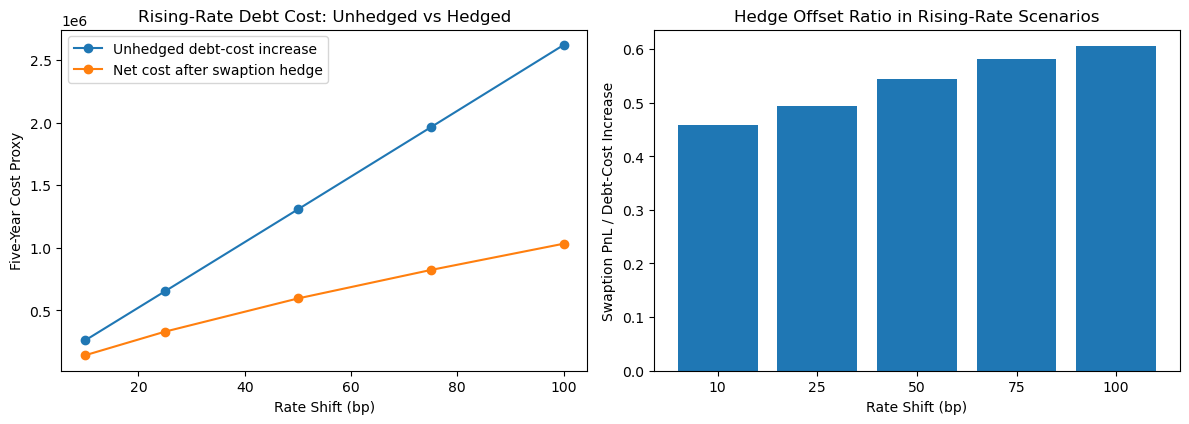

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(rising_df['rate_shift_bp'], rising_df['five_year_total_cost_change'], marker='o', label='Unhedged debt-cost increase')
axes[0].plot(rising_df['rate_shift_bp'], rising_df['net_cost_after_hedge'], marker='o', label='Net cost after swaption hedge')
axes[0].set_title('Rising-Rate Debt Cost: Unhedged vs Hedged')
axes[0].set_xlabel('Rate Shift (bp)')
axes[0].set_ylabel('Five-Year Cost Proxy')
axes[0].legend()

axes[1].bar(rising_df['rate_shift_bp'].astype(int).astype(str), rising_df['hedge_offset_ratio'])
axes[1].set_title('Hedge Offset Ratio in Rising-Rate Scenarios')
axes[1].set_xlabel('Rate Shift (bp)')
axes[1].set_ylabel('Swaption PnL / Debt-Cost Increase')

plt.tight_layout()
plt.show()


## Suggested Visuals for Hedge Interpretation

The most useful corporate-treasury visuals are:

1. `Future funding-rate proxy by scenario point`
2. `Five-year debt-cost change without hedge`
3. `Swaption PnL under each scenario`
4. `Unhedged cost vs net cost after hedge`

Together these show whether the hedge is expensive insurance, neutral carry, or valuable protection depending on the rate path.


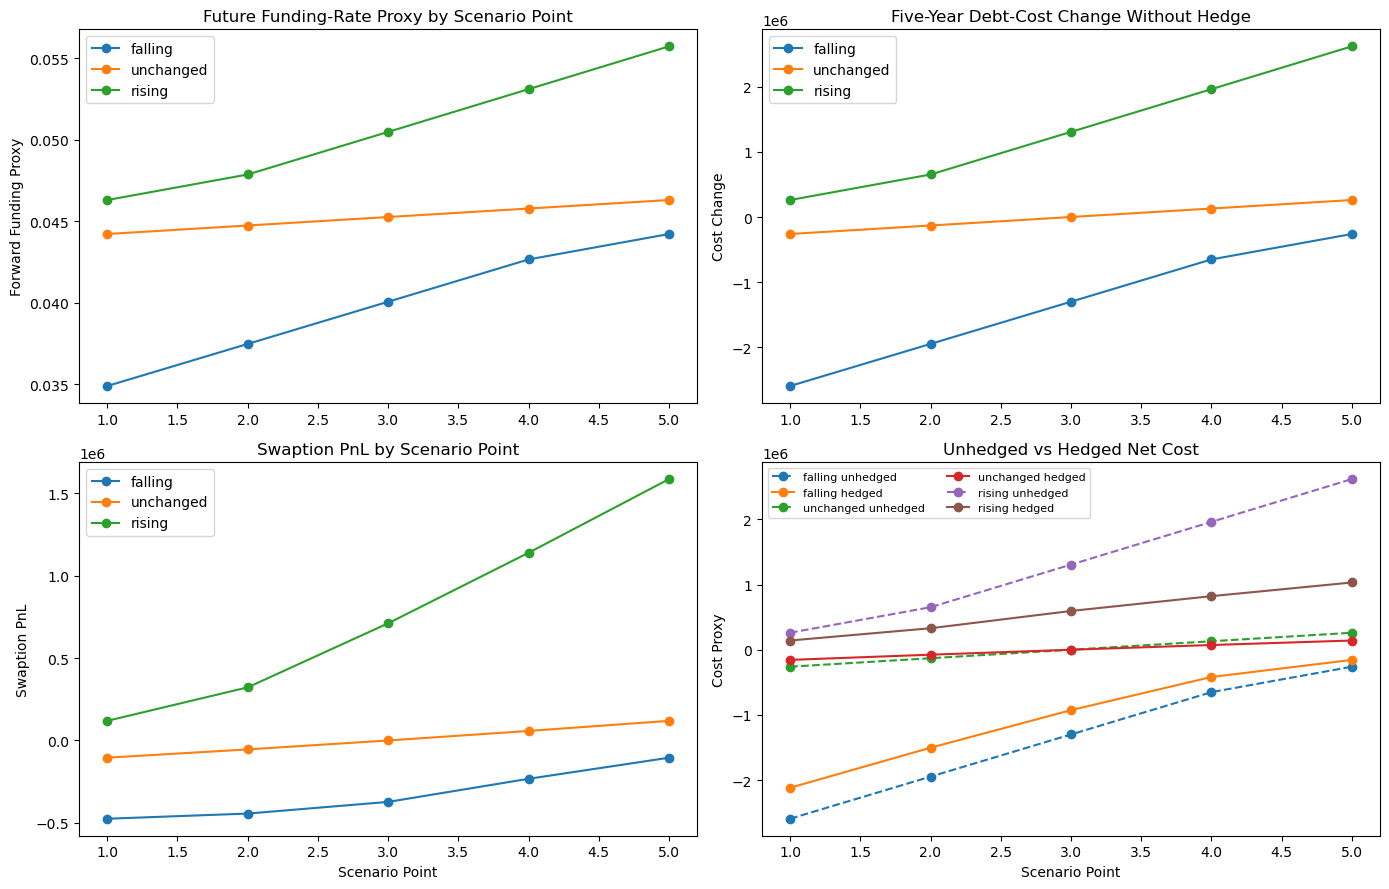

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)

for regime_name in ['falling', 'unchanged', 'rising']:
    subset = scenario_df[scenario_df['regime'] == regime_name]
    axes[0, 0].plot(subset['scenario_point'], subset['future_funding_rate_proxy'], marker='o', label=regime_name)
    axes[0, 1].plot(subset['scenario_point'], subset['five_year_total_cost_change'], marker='o', label=regime_name)
    axes[1, 0].plot(subset['scenario_point'], subset['swaption_pnl'], marker='o', label=regime_name)
    axes[1, 1].plot(subset['scenario_point'], subset['five_year_total_cost_change'], marker='o', linestyle='--', label=f'{regime_name} unhedged')
    axes[1, 1].plot(subset['scenario_point'], subset['net_cost_after_hedge'], marker='o', label=f'{regime_name} hedged')

axes[0, 0].set_title('Future Funding-Rate Proxy by Scenario Point')
axes[0, 0].set_ylabel('Forward Funding Proxy')
axes[0, 0].legend()

axes[0, 1].set_title('Five-Year Debt-Cost Change Without Hedge')
axes[0, 1].set_ylabel('Cost Change')
axes[0, 1].legend()

axes[1, 0].set_title('Swaption PnL by Scenario Point')
axes[1, 0].set_ylabel('Swaption PnL')
axes[1, 0].set_xlabel('Scenario Point')
axes[1, 0].legend()

axes[1, 1].set_title('Unhedged vs Hedged Net Cost')
axes[1, 1].set_ylabel('Cost Proxy')
axes[1, 1].set_xlabel('Scenario Point')
axes[1, 1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


## Interpretation

- In the `falling` regime, the company's future funding rate improves on its own, so the payer swaption tends to lose value; this is the cost of having bought insurance that turns out not to be needed.
- In the `unchanged` regime, the hedge mostly behaves like an insurance premium with limited offset effect.
- In the `rising` regime, the company faces materially worse future funding levels, but the payer swaption gains value and offsets part of the increase in issuance cost.
- The rising-rate focus charts make the hedge benefit more explicit: as issuance cost rises, the swaption absorbs part of that shock, leaving a smaller net funding-cost increase.
- The key treasury question is not whether the option always makes money, but whether it reduces the sensitivity of future debt issuance cost to adverse rate moves.
- This notebook therefore emphasizes `net funding-cost impact after hedge`, which is the most business-relevant metric for a future bond issuance decision.

## Practical Limitations

- The curve is a public-data Treasury proxy, not a dealer-grade SOFR swap curve.
- The volatility inputs are still project assumptions rather than a real market swaption vol slice.
- The debt-cost comparison is simplified and uses swap-rate changes as a proxy for future bond issuance spread-free funding cost.
- The scenarios are deterministic parallel-rate shifts rather than a full joint model of benchmark rates, credit spreads, and issuance timing.
